# generate_orographic_smoothing_coefficients 模块验证

本 Notebook 用于验证地形平滑系数生成在两类空间坐标下的迁移结果。

章节组织：

1. **投影坐标输入** — 官方投影地形/掩码 → meb 六维（`lat`/`lon` 为距离坐标，`units` 可转米），与原 Improver / KGO 对照
2. **经纬坐标输入** — 重网格到规则经纬后，同一经纬输入上对比修改后方法与原方法（**不与投影 KGO 对比**）

投影坐标章节下再分为：

- 数据预处理
- **算法运行与数值对比**
- **输入数据绘图**
- **输出对比绘图**

经纬坐标章节仅做数据预处理、算法运行与数值对比、输出对比绘图（输入来自同一套投影官方样例的重网格，不再重复绘制输入图）。

末尾单独给出 **CLI 应用示例与结果对比**。


## 环境准备



In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import iris

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "generate_orographic_smoothing_coefficients").exists():
    # Notebook 若从模块目录启动，则回退到仓库根
    ROOT_DIR = Path.cwd().parents[0] if (Path.cwd().name == "nbs") else Path.cwd()
    while ROOT_DIR.name and not (ROOT_DIR / "generate_orographic_smoothing_coefficients").exists():
        if ROOT_DIR.parent == ROOT_DIR:
            break
        ROOT_DIR = ROOT_DIR.parent

for p in (ROOT_DIR, ROOT_DIR / "improver-1.18.7"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from generate_orographic_smoothing_coefficients.src.generate_orographic_smoothing_coefficients import (
    OrographicSmoothingCoefficients,
)
from improver.generate_ancillaries.generate_orographic_smoothing_coefficients import (  # pyright: ignore[reportMissingImports]
    OrographicSmoothingCoefficients as OrigPlugin,
)

TEST_ROOT = ROOT_DIR / "generate_orographic_smoothing_coefficients" / "test_data"
CLI_INPUTS = TEST_ROOT / "cli_inputs"
CLI_OUTPUTS = TEST_ROOT / "cli_outputs"
CLI_INPUTS.mkdir(parents=True, exist_ok=True)
CLI_OUTPUTS.mkdir(parents=True, exist_ok=True)

print("ROOT_DIR:", ROOT_DIR)
print("TEST_ROOT:", TEST_ROOT)



d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


ROOT_DIR: d:\workspace\improver
TEST_ROOT: d:\workspace\improver\generate_orographic_smoothing_coefficients\test_data


## 投影坐标输入

### 1. 数据预处理

将官方 Iris 2D 投影场转为 meb 六维：维度名仍用 `lat`/`lon`，但坐标 `units` 为米，并写入 `grid_mapping_attrs`。



In [2]:
def make_meb6d(
    values_2d,
    *,
    lat,
    lon,
    name,
    lat_units="m",
    lon_units="m",
    units="m",
    grid_mapping_attrs=None,
):
    """构造投影路径六维场。

    - ``lat_units`` / ``lon_units``：空间坐标单位（可转米）
    - ``units``：场本身单位（地形为 ``m``，掩码为 ``1``），从原 Cube 继承，勿写死
    """
    values = np.asarray(values_2d, dtype=np.float32)[None, None, None, None, :, :]
    mapping = grid_mapping_attrs or {"grid_mapping_name": "lambert_azimuthal_equal_area"}
    return xr.DataArray(
        values,
        dims=("member", "level", "time", "dtime", "lat", "lon"),
        coords={
            "member": [0],
            "level": [0],
            "time": np.array(["2018-04-19T00:00:00"], dtype="datetime64[ns]"),
            "dtime": [0],
            "lat": xr.DataArray(np.asarray(lat, dtype=np.float32), dims=("lat",), attrs={"units": lat_units}),
            "lon": xr.DataArray(np.asarray(lon, dtype=np.float32), dims=("lon",), attrs={"units": lon_units}),
        },
        attrs={"units": units, "grid_mapping_attrs": json.dumps(mapping, ensure_ascii=False)},
        name=name,
    )


def iris_cube_to_meb6d(cube):
    y = cube.coord(axis="y")
    x = cube.coord(axis="x")
    mapping = {}
    if cube.coord_system() is not None:
        try:
            mapping = dict(cube.coord_system().as_cartopy_crs().to_cf())
        except Exception:
            mapping = {"grid_mapping_name": "unknown"}
    return make_meb6d(
        np.asarray(cube.data, dtype=np.float32),
        lat=y.points,
        lon=x.points,
        name=cube.name() or "field",
        lat_units=str(y.units),
        lon_units=str(x.units),
        units=str(cube.units),
        grid_mapping_attrs=mapping or None,
    )


def to_2d(da):
    arr = np.asarray(da.values if hasattr(da, "values") else da.data, dtype=np.float64)
    return np.squeeze(arr)


def summarize(name, a, b, c=None):
    a2, b2 = to_2d(a), to_2d(b)
    diff_ab = a2 - b2
    print(
        f"[{name}] 修改后方法 vs 原方法: "
        f"max_abs={np.nanmax(np.abs(diff_ab)):.3e}, "
        f"rmse={np.sqrt(np.nanmean(diff_ab * diff_ab)):.3e}"
    )
    if c is not None:
        c2 = to_2d(c)
        diff_ac = a2 - c2
        print(
            f"[{name}] 修改后方法 vs KGO:      "
            f"max_abs={np.nanmax(np.abs(diff_ac)):.3e}, "
            f"rmse={np.sqrt(np.nanmean(diff_ac * diff_ac)):.3e}"
        )


def plot_triplet(title, current, original, kgo):
    """三列对比；投影坐标以 km 显示。"""
    arrays = [to_2d(current), to_2d(original), to_2d(kgo)]
    y_km = np.asarray(current.coords["lat"].values, dtype=np.float64) / 1000.0
    x_km = np.asarray(current.coords["lon"].values, dtype=np.float64) / 1000.0
    xx, yy = np.meshgrid(x_km, y_km)
    vmin = float(np.nanmin([np.nanmin(a) for a in arrays]))
    vmax = float(np.nanmax([np.nanmax(a) for a in arrays]))
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=False, sharey=False)
    for ax, arr, label in zip(axes, arrays, ["修改后方法", "原方法", "KGO"]):
        im = ax.pcolormesh(
            xx, yy, arr, shading="auto", vmin=vmin, vmax=vmax, cmap="viridis"
        )
        ax.set_title(label)
        ax.set_xlabel("x / km")
        ax.set_ylabel("y / km")
        ax.set_aspect("equal", adjustable="box")
        ax.tick_params(labelleft=True, labelbottom=True)
        ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=5))
        for tick in ax.get_xticklabels():
            tick.set_rotation(30)
            tick.set_ha("right")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


orog_cube = iris.load_cube(str(TEST_ROOT / "orography.nc"))
land_cube = iris.load_cube(str(TEST_ROOT / "landmask.nc"))
orog = iris_cube_to_meb6d(orog_cube)
land = iris_cube_to_meb6d(land_cube)

print("orography:", orog.name, orog.shape, "lat units=", orog.coords["lat"].attrs.get("units"))
print("landmask:", land.name, land.shape)

# 导出 CLI 默认可读输入
orog_path = CLI_INPUTS / "input_orography_meb.nc"
land_path = CLI_INPUTS / "input_landmask_meb.nc"
orog.to_netcdf(orog_path)
land.to_netcdf(land_path)
print("wrote:", orog_path)
print("wrote:", land_path)



orography: surface_altitude (1, 1, 1, 1, 100, 100) lat units= m
landmask: land_binary_mask (1, 1, 1, 1, 100, 100)
wrote: d:\workspace\improver\generate_orographic_smoothing_coefficients\test_data\cli_inputs\input_orography_meb.nc
wrote: d:\workspace\improver\generate_orographic_smoothing_coefficients\test_data\cli_inputs\input_landmask_meb.nc


### 2. OrographicSmoothingCoefficients

覆盖 acceptance 中的：`basic`、不同 limits、不同 power、`mask_boundary`、`mask_zeroed`、`inverse_mask_zeroed`。



#### 2.1 算法运行与数值对比



In [3]:
CASES = [
    {
        "name": "basic",
        "subdir": "basic",
        "kgo": "kgo.nc",
        "use_mask": False,
        "kwargs": {
            "min_gradient_smoothing_coefficient": 0.5,
            "max_gradient_smoothing_coefficient": 0.0,
        },
    },
    {
        "name": "basic_different_limits",
        "subdir": "basic",
        "kgo": "kgo_different_limits.nc",
        "use_mask": False,
        "kwargs": {
            "min_gradient_smoothing_coefficient": 0.25,
            "max_gradient_smoothing_coefficient": 0.0,
        },
    },
    {
        "name": "basic_different_power",
        "subdir": "basic",
        "kgo": "kgo_different_power.nc",
        "use_mask": False,
        "kwargs": {"power": 0.5},
    },
    {
        "name": "mask_boundary",
        "subdir": "mask_boundary",
        "kgo": "kgo.nc",
        "use_mask": True,
        "kwargs": {
            "min_gradient_smoothing_coefficient": 0.5,
            "max_gradient_smoothing_coefficient": 0.0,
            "use_mask_boundary": True,
        },
    },
    {
        "name": "mask_zeroed",
        "subdir": "mask_zeroed",
        "kgo": "kgo.nc",
        "use_mask": True,
        "kwargs": {
            "min_gradient_smoothing_coefficient": 0.5,
            "max_gradient_smoothing_coefficient": 0.0,
        },
    },
    {
        "name": "inverse_mask_zeroed",
        "subdir": "inverse_mask_zeroed",
        "kgo": "kgo.nc",
        "use_mask": True,
        "kwargs": {
            "min_gradient_smoothing_coefficient": 0.5,
            "max_gradient_smoothing_coefficient": 0.0,
            "invert_mask": True,
        },
    },
]

results = {}
for case in CASES:
    mask = land if case["use_mask"] else None
    mask_cube = land_cube if case["use_mask"] else None
    # 修改后方法调用
    cur_x, cur_y = OrographicSmoothingCoefficients(**case["kwargs"]).process(orog, mask=mask)
    # 原方法调用
    orig = OrigPlugin(**case["kwargs"])(orog_cube, mask_cube)
    orig_x = orig.extract_cube("smoothing_coefficient_x")
    orig_y = orig.extract_cube("smoothing_coefficient_y")
    kgo = iris.load(str(TEST_ROOT / case["subdir"] / case["kgo"]))
    kgo_x = kgo.extract_cube("smoothing_coefficient_x")
    kgo_y = kgo.extract_cube("smoothing_coefficient_y")

    print("===", case["name"], "===")
    summarize("x", cur_x, orig_x, kgo_x)
    summarize("y", cur_y, orig_y, kgo_y)
    results[case["name"]] = {
        "cur_x": cur_x,
        "cur_y": cur_y,
        "orig_x": orig_x,
        "orig_y": orig_y,
        "kgo_x": kgo_x,
        "kgo_y": kgo_y,
    }



=== basic ===
[x] 修改后方法 vs 原方法: max_abs=5.960e-08, rmse=1.772e-09
[x] 修改后方法 vs KGO:      max_abs=5.960e-08, rmse=1.772e-09
[y] 修改后方法 vs 原方法: max_abs=5.960e-08, rmse=1.556e-09
[y] 修改后方法 vs KGO:      max_abs=5.960e-08, rmse=1.556e-09
=== basic_different_limits ===
[x] 修改后方法 vs 原方法: max_abs=2.980e-08, rmse=8.860e-10
[x] 修改后方法 vs KGO:      max_abs=2.980e-08, rmse=8.860e-10
[y] 修改后方法 vs 原方法: max_abs=2.980e-08, rmse=7.782e-10
[y] 修改后方法 vs KGO:      max_abs=2.980e-08, rmse=7.782e-10
=== basic_different_power ===
[x] 修改后方法 vs 原方法: max_abs=2.980e-08, rmse=1.694e-09
[x] 修改后方法 vs KGO:      max_abs=2.980e-08, rmse=1.694e-09
[y] 修改后方法 vs 原方法: max_abs=2.980e-08, rmse=1.306e-09
[y] 修改后方法 vs KGO:      max_abs=2.980e-08, rmse=1.306e-09
=== mask_boundary ===
[x] 修改后方法 vs 原方法: max_abs=5.960e-08, rmse=1.772e-09
[x] 修改后方法 vs KGO:      max_abs=5.960e-08, rmse=1.772e-09
[y] 修改后方法 vs 原方法: max_abs=5.960e-08, rmse=1.556e-09
[y] 修改后方法 vs KGO:      max_abs=5.960e-08, rmse=1.556e-09
=== mask_zeroed ===
[x] 修改后方法 v

#### 2.2 输入数据绘图

绘制预处理后的投影坐标输入：地形与海陆掩码。

说明：数据坐标仍为米；为避免大数值刻度重叠，**图轴以 km 显示**。



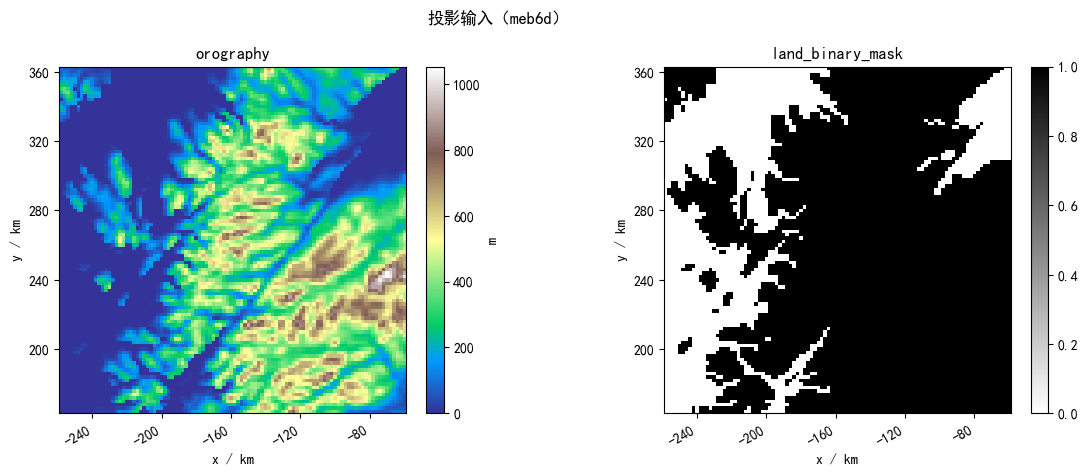

orography range: 0.0 1052.1121826171875
landmask unique: [0. 1.]


In [4]:
orog_2d = to_2d(orog)
land_2d = to_2d(land)
y_km = np.asarray(orog.coords["lat"].values, dtype=np.float64) / 1000.0
x_km = np.asarray(orog.coords["lon"].values, dtype=np.float64) / 1000.0
xx, yy = np.meshgrid(x_km, y_km)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=False, sharey=False)
im0 = axes[0].pcolormesh(xx, yy, orog_2d, shading="auto", cmap="terrain")
axes[0].set_title("orography")
axes[0].set_xlabel("x / km")
axes[0].set_ylabel("y / km")
axes[0].set_aspect("equal", adjustable="box")
axes[0].xaxis.set_major_locator(plt.MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(plt.MaxNLocator(nbins=5))
for tick in axes[0].get_xticklabels():
    tick.set_rotation(30)
    tick.set_ha("right")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="m")

im1 = axes[1].pcolormesh(xx, yy, land_2d, shading="auto", cmap="gray_r")
axes[1].set_title("land_binary_mask")
axes[1].set_xlabel("x / km")
axes[1].set_ylabel("y / km")
axes[1].set_aspect("equal", adjustable="box")
axes[1].xaxis.set_major_locator(plt.MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(plt.MaxNLocator(nbins=5))
for tick in axes[1].get_xticklabels():
    tick.set_rotation(30)
    tick.set_ha("right")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle("投影输入（meb6d）")
plt.tight_layout()
plt.show()

print("orography range:", float(np.nanmin(orog_2d)), float(np.nanmax(orog_2d)))
print("landmask unique:", np.unique(land_2d))



#### 2.3 输出对比绘图

以 `basic` 与 `mask_boundary` 为例；三列按投影坐标出图（图轴为 km；修改后方法 | 原方法 | KGO）。



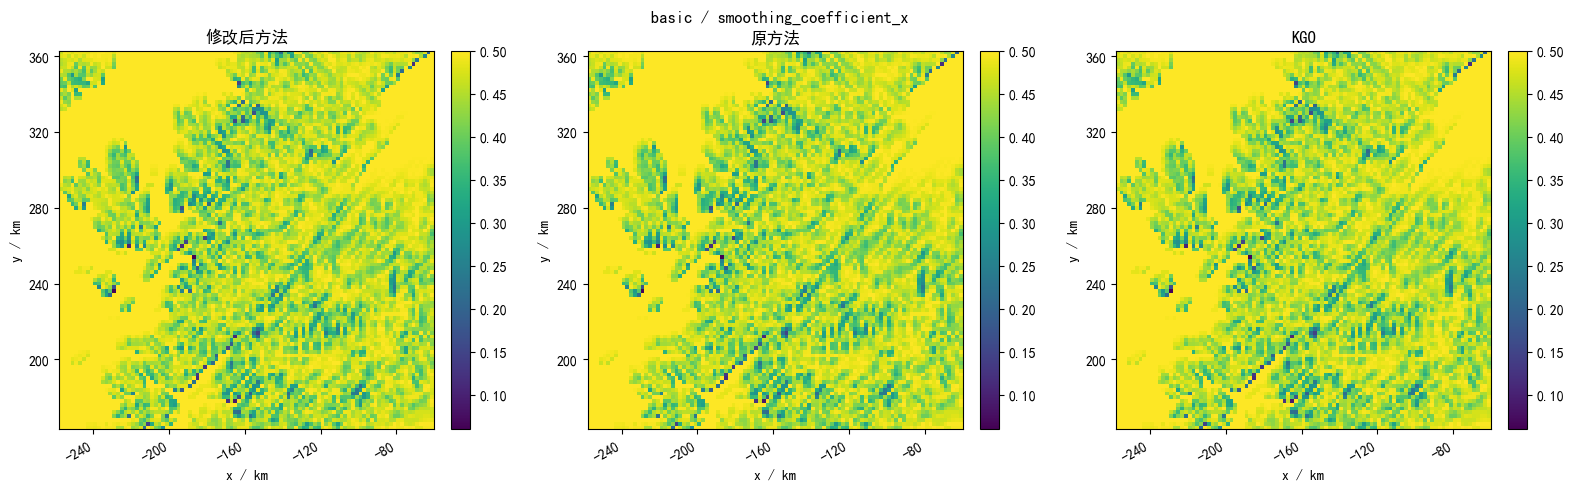

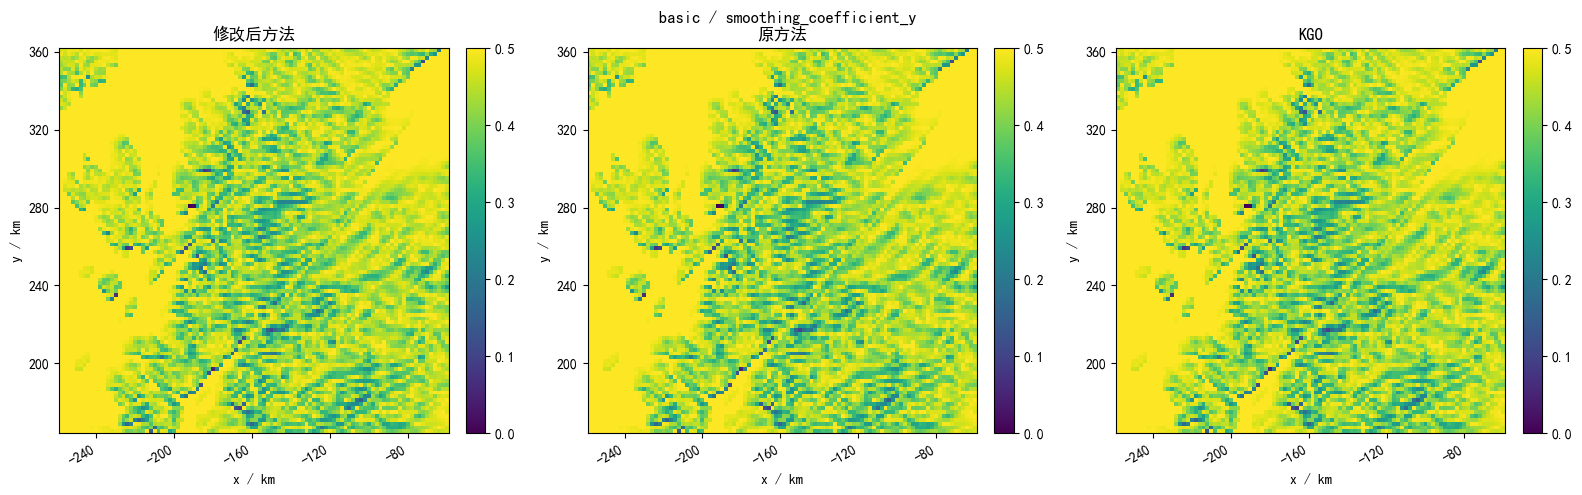

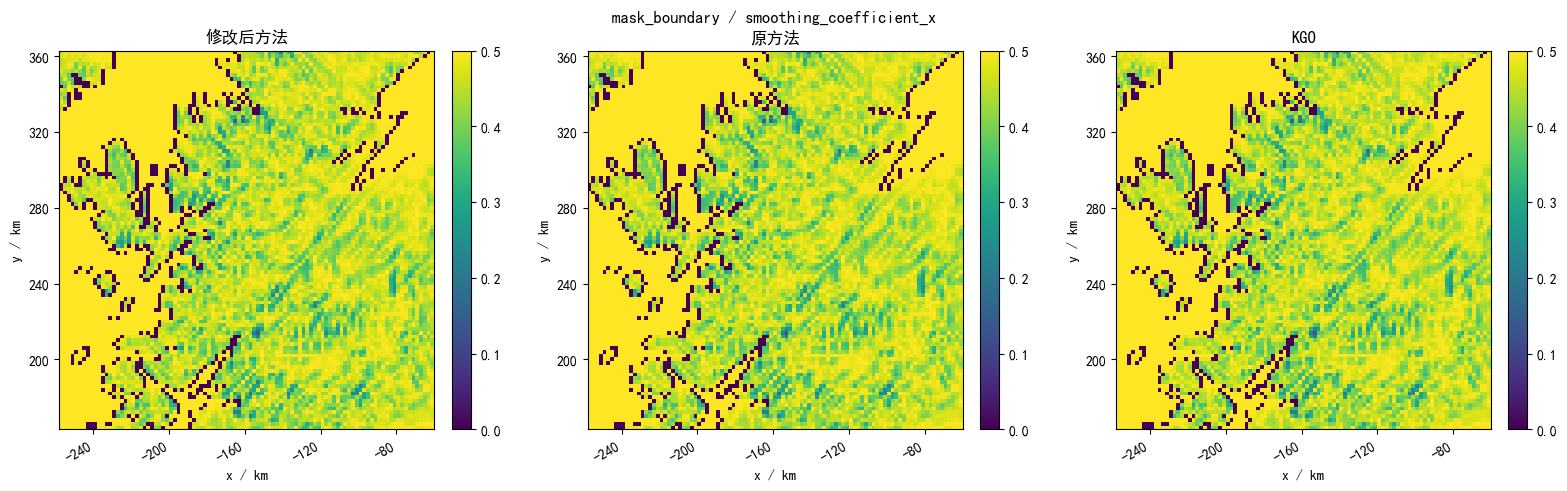

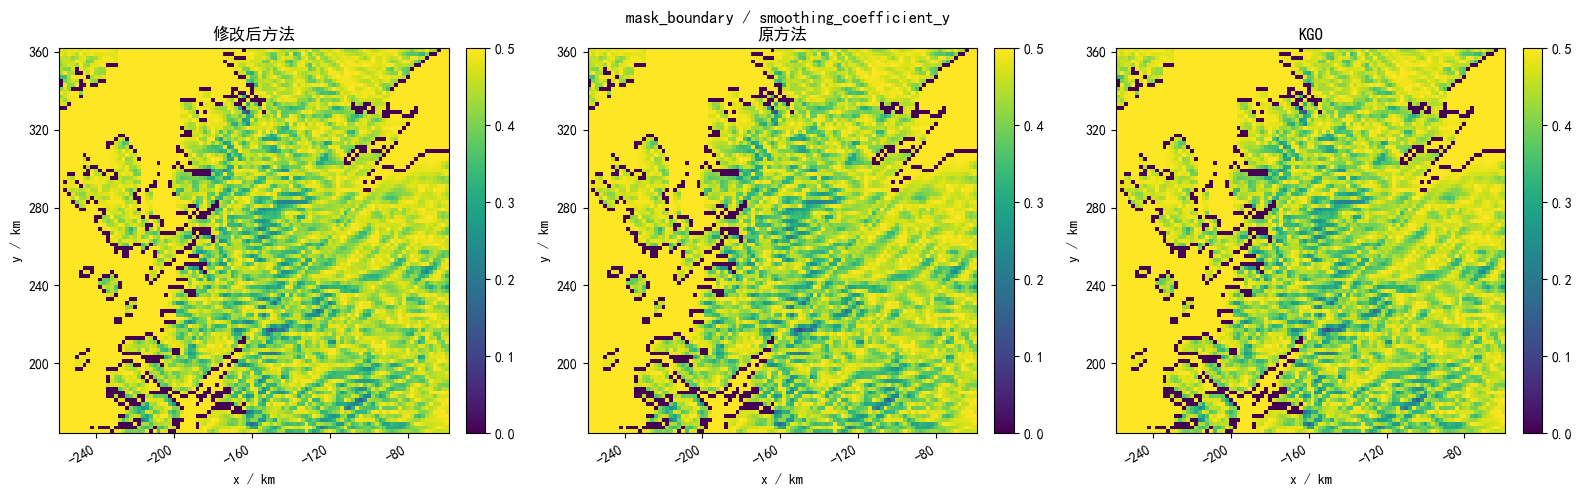

In [5]:
for key in ("basic", "mask_boundary"):
    r = results[key]
    plot_triplet(f"{key} / smoothing_coefficient_x", r["cur_x"], r["orig_x"], r["kgo_x"])
    plot_triplet(f"{key} / smoothing_coefficient_y", r["cur_y"], r["orig_y"], r["kgo_y"])



## 经纬坐标输入

将输入重网格到规则经纬网格后，在同一经纬输入上跑原 Improver 与修改后方法。

结果对比不再使用 KGO：`KGO` 为投影坐标结果，与经纬上重算因坐标系（梯度格距）不同，不宜作为经纬分支判据。

### 1. 数据预处理



In [6]:
def make_meb6d_latlon(
    values_2d, *, lat, lon, name, lat_units=None, lon_units=None, units="m"
):
    """创建经纬度输入的六维 DataArray（无 grid_mapping_attrs）。

    注意：经纬坐标保持 float64。若降为 float32，球面格距会有明显误差。
    """
    values = np.asarray(values_2d, dtype=np.float32)[None, None, None, None, :, :]
    lat_attrs = {"units": lat_units} if lat_units else {}
    lon_attrs = {"units": lon_units} if lon_units else {}
    return xr.DataArray(
        values,
        dims=("member", "level", "time", "dtime", "lat", "lon"),
        coords={
            "member": [0],
            "level": [0],
            "time": np.array(["2018-04-19T00:00:00"], dtype="datetime64[ns]"),
            "dtime": [0],
            "lat": xr.DataArray(np.asarray(lat, dtype=np.float64), dims=("lat",), attrs=lat_attrs),
            "lon": xr.DataArray(np.asarray(lon, dtype=np.float64), dims=("lon",), attrs=lon_attrs),
        },
        attrs={"units": units},
        name=name,
    )


def cube_data_to_float32(cube):
    """Iris 数据 -> float32；掩码位置填 NaN。"""
    arr = np.ma.asarray(cube.data).astype(np.float64)
    return np.ma.filled(arr, np.nan).astype(np.float32)


def iris_latlon_cube_to_meb6d(cube, *, name=None, lat_units=None, lon_units=None):
    """已是经纬网格的 Iris Cube -> meb 六维。"""
    return make_meb6d_latlon(
        cube_data_to_float32(cube),
        lat=cube.coord("latitude").points,
        lon=cube.coord("longitude").points,
        name=name or cube.name() or "field",
        lat_units=lat_units,
        lon_units=lon_units,
        units=str(cube.units),
    )


def build_regular_latlon_target(cube, resolution=0.01, sphere_radius=6371229.0):
    """由投影场角点范围构造统一规则经纬目标网格。"""
    import cartopy.crs as ccrs
    from iris.coord_systems import GeogCS
    from iris.coords import DimCoord
    from iris.cube import Cube

    cs = cube.coord_system()
    if cs is None:
        raise ValueError("Cube 没有坐标系统，无法投影到经纬。")
    src_crs = cs.as_cartopy_crs()
    target_crs = ccrs.PlateCarree()
    y_coord = cube.coord(axis="y")
    x_coord = cube.coord(axis="x")
    xx, yy = np.meshgrid(
        [x_coord.points[0], x_coord.points[-1]],
        [y_coord.points[0], y_coord.points[-1]],
    )
    transform = target_crs.transform_points(src_crs, xx, yy)
    lat_min, lat_max = float(transform[:, :, 1].min()), float(transform[:, :, 1].max())
    lon_min, lon_max = float(transform[:, :, 0].min()), float(transform[:, :, 0].max())
    target_lat = np.arange(lat_min, lat_max + resolution * 0.5, resolution)
    target_lon = np.arange(lon_min, lon_max + resolution * 0.5, resolution)
    geog = GeogCS(sphere_radius)
    lat_coord = DimCoord(
        target_lat, standard_name="latitude", units="degrees", coord_system=geog
    )
    lon_coord = DimCoord(
        target_lon, standard_name="longitude", units="degrees", coord_system=geog
    )
    return Cube(
        np.zeros((target_lat.size, target_lon.size), dtype=np.float32),
        dim_coords_and_dims=[(lat_coord, 0), (lon_coord, 1)],
    )


def regrid_to_target(cube, target_grid, *, scheme="linear"):
    """重网格到统一目标网格。

    说明：投影矩形映射到经纬后，并不能填满整个 lat/lon bbox。
    验证场景使用 extrapolate 填满，避免边缘缺测在梯度中扩散造成假差异。
    """
    from iris.analysis import Linear, Nearest

    if scheme == "nearest":
        regridder = Nearest(extrapolation_mode="extrapolate")
    else:
        regridder = Linear(extrapolation_mode="extrapolate")
    return cube.regrid(target_grid, regridder)


def summarize_pair(name, a, b):
    """对比两个结果场。"""
    a2, b2 = to_2d(a), to_2d(b)
    if a2.shape != b2.shape:
        print(f"[{name}] shape mismatch: {a2.shape} vs {b2.shape}")
        return
    both = np.isfinite(a2) & np.isfinite(b2)
    diff = a2[both] - b2[both]
    print(
        f"[{name}] 修改后方法 vs 原方法: "
        f"max_abs={np.max(np.abs(diff)):.3e} "
        f"rmse={np.sqrt(np.mean(diff * diff)):.3e}"
    )


def plot_pair(title, current, original):
    """两列对比：修改后方法 | 原方法，横纵坐标为经纬度。"""
    arrays = [to_2d(current), to_2d(original)]
    lat = np.asarray(current.coords["lat"].values, dtype=np.float64)
    lon = np.asarray(current.coords["lon"].values, dtype=np.float64)

    lon2d, lat2d = np.meshgrid(lon, lat)
    vmin = float(np.nanmin([np.nanmin(x) for x in arrays]))
    vmax = float(np.nanmax([np.nanmax(x) for x in arrays]))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=False, sharey=False)
    for ax, arr, label in zip(axes, arrays, ["修改后方法", "原方法"]):
        im = ax.pcolormesh(
            lon2d,
            lat2d,
            arr,
            shading="auto",
            vmin=vmin,
            vmax=vmax,
            cmap="viridis",
        )
        ax.set_title(label)
        ax.set_xlabel("longitude")
        ax.set_ylabel("latitude")
        ax.set_aspect("equal", adjustable="box")
        ax.tick_params(labelleft=True, labelbottom=True)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


orog_cube = iris.load_cube(str(TEST_ROOT / "orography.nc"))
land_cube = iris.load_cube(str(TEST_ROOT / "landmask.nc"))

resolution = 0.01
sphere_radius = 6371229.0  # 与 Improver / Iris GeogCS 常用默认一致
target_grid = build_regular_latlon_target(
    orog_cube, resolution=resolution, sphere_radius=sphere_radius
)

orog_latlon_cube = regrid_to_target(orog_cube, target_grid, scheme="linear")
land_latlon_cube = regrid_to_target(land_cube, target_grid, scheme="nearest")

# 掩码二值化
land_bin = (cube_data_to_float32(land_latlon_cube) >= 0.5).astype(np.float32)
land_latlon_cube = land_latlon_cube.copy(data=land_bin)

print("=== 预处理完成（经纬输入） ===")
print("orography:", orog_latlon_cube.shape)
print("landmask:", land_latlon_cube.shape)
print(
    "orog finite:",
    float(np.isfinite(cube_data_to_float32(orog_latlon_cube)).mean()),
    "land unique:",
    np.unique(cube_data_to_float32(land_latlon_cube)),
)


=== 预处理完成（经纬输入） ===
orography: (185, 341)
landmask: (185, 341)
orog finite: 1.0 land unique: [0. 1.]


### 2. OrographicSmoothingCoefficients

覆盖与投影分支相同的 acceptance 场景。经纬分支判据为同一经纬输入下「修改后方法 vs 原方法」。



#### 2.1 算法运行与数值对比



In [7]:
CASES = [
    {
        "name": "basic",
        "use_mask": False,
        "kwargs": {
            "min_gradient_smoothing_coefficient": 0.5,
            "max_gradient_smoothing_coefficient": 0.0,
        },
    },
    {
        "name": "basic_different_limits",
        "use_mask": False,
        "kwargs": {
            "min_gradient_smoothing_coefficient": 0.25,
            "max_gradient_smoothing_coefficient": 0.0,
        },
    },
    {
        "name": "basic_different_power",
        "use_mask": False,
        "kwargs": {"power": 0.5},
    },
    {
        "name": "mask_boundary",
        "use_mask": True,
        "kwargs": {
            "min_gradient_smoothing_coefficient": 0.5,
            "max_gradient_smoothing_coefficient": 0.0,
            "use_mask_boundary": True,
        },
    },
    {
        "name": "mask_zeroed",
        "use_mask": True,
        "kwargs": {
            "min_gradient_smoothing_coefficient": 0.5,
            "max_gradient_smoothing_coefficient": 0.0,
        },
    },
    {
        "name": "inverse_mask_zeroed",
        "use_mask": True,
        "kwargs": {
            "min_gradient_smoothing_coefficient": 0.5,
            "max_gradient_smoothing_coefficient": 0.0,
            "invert_mask": True,
        },
    },
]

# 经纬输入：Iris Cube 用于原方法；meb 六维用于修改后方法
orog_meb = iris_latlon_cube_to_meb6d(orog_latlon_cube, lat_units=None, lon_units=None)
land_meb = iris_latlon_cube_to_meb6d(land_latlon_cube, lat_units=None, lon_units=None)

latlon_results = {}
for case in CASES:
    mask = land_meb if case["use_mask"] else None
    mask_cube = land_latlon_cube if case["use_mask"] else None
    # 修改后方法调用
    cur_x, cur_y = OrographicSmoothingCoefficients(**case["kwargs"]).process(
        orog_meb, mask=mask
    )
    # 原方法调用
    orig = OrigPlugin(**case["kwargs"])(orog_latlon_cube, mask_cube)
    orig_x = orig.extract_cube("smoothing_coefficient_x")
    orig_y = orig.extract_cube("smoothing_coefficient_y")

    print("===", case["name"], "===")
    summarize_pair("coeff_x", cur_x, orig_x)
    summarize_pair("coeff_y", cur_y, orig_y)
    latlon_results[case["name"]] = {
        "cur_x": cur_x,
        "cur_y": cur_y,
        "orig_x": orig_x,
        "orig_y": orig_y,
    }



=== basic ===
[coeff_x] 修改后方法 vs 原方法: max_abs=5.960e-08 rmse=4.666e-09
[coeff_y] 修改后方法 vs 原方法: max_abs=5.960e-08 rmse=4.646e-09
=== basic_different_limits ===
[coeff_x] 修改后方法 vs 原方法: max_abs=2.980e-08 rmse=2.333e-09
[coeff_y] 修改后方法 vs 原方法: max_abs=2.980e-08 rmse=2.323e-09
=== basic_different_power ===
[coeff_x] 修改后方法 vs 原方法: max_abs=5.960e-08 rmse=6.118e-09
[coeff_y] 修改后方法 vs 原方法: max_abs=5.960e-08 rmse=5.883e-09
=== mask_boundary ===
[coeff_x] 修改后方法 vs 原方法: max_abs=5.960e-08 rmse=4.607e-09
[coeff_y] 修改后方法 vs 原方法: max_abs=5.960e-08 rmse=4.455e-09
=== mask_zeroed ===
[coeff_x] 修改后方法 vs 原方法: max_abs=5.960e-08 rmse=1.076e-09
[coeff_y] 修改后方法 vs 原方法: max_abs=2.980e-08 rmse=1.010e-09
=== inverse_mask_zeroed ===
[coeff_x] 修改后方法 vs 原方法: max_abs=5.960e-08 rmse=4.479e-09
[coeff_y] 修改后方法 vs 原方法: max_abs=5.960e-08 rmse=4.339e-09


#### 2.2 输出对比绘图

以 `basic` 与 `mask_boundary` 为例；经纬分支两列对比（修改后方法 | 原方法）。


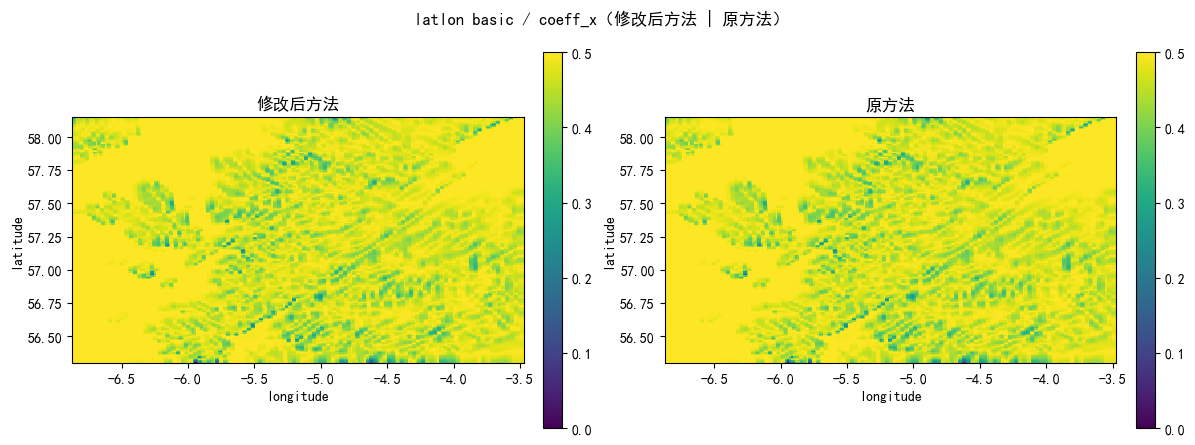

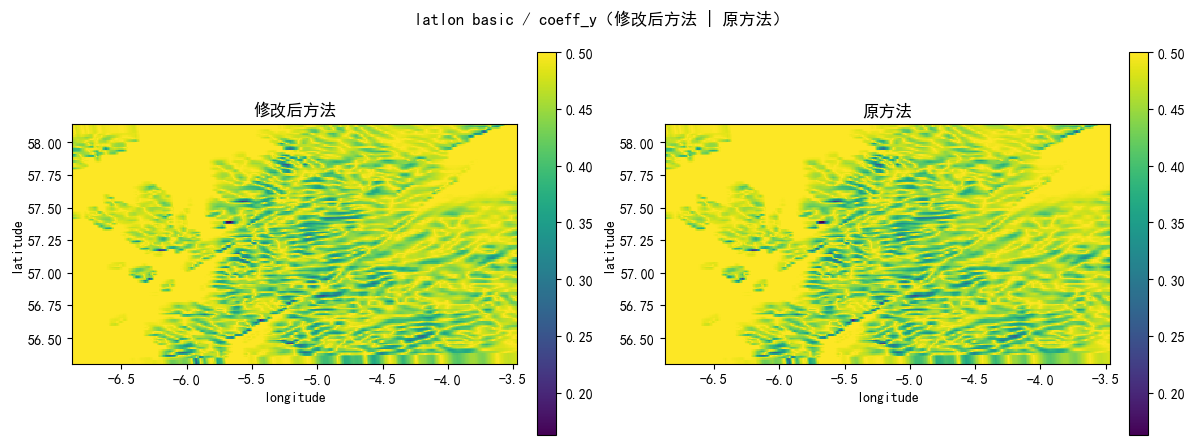

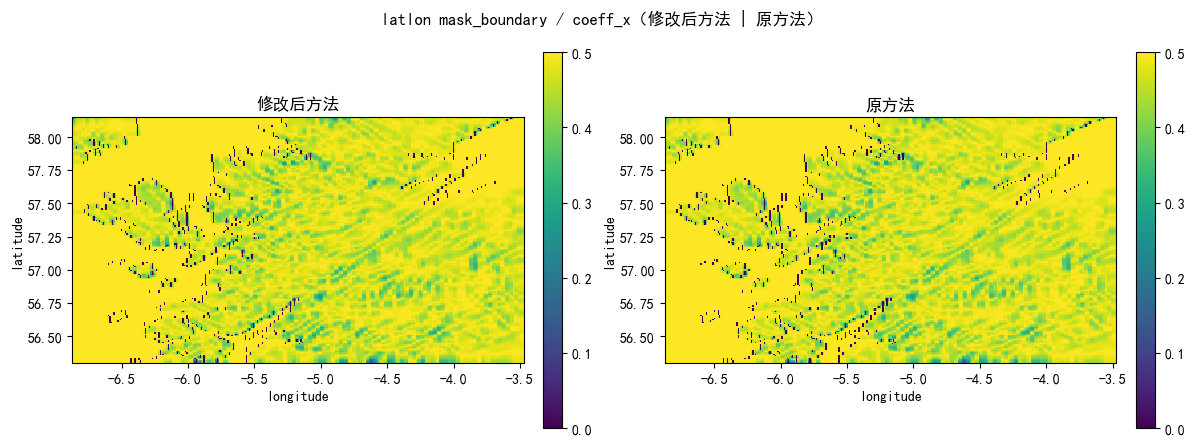

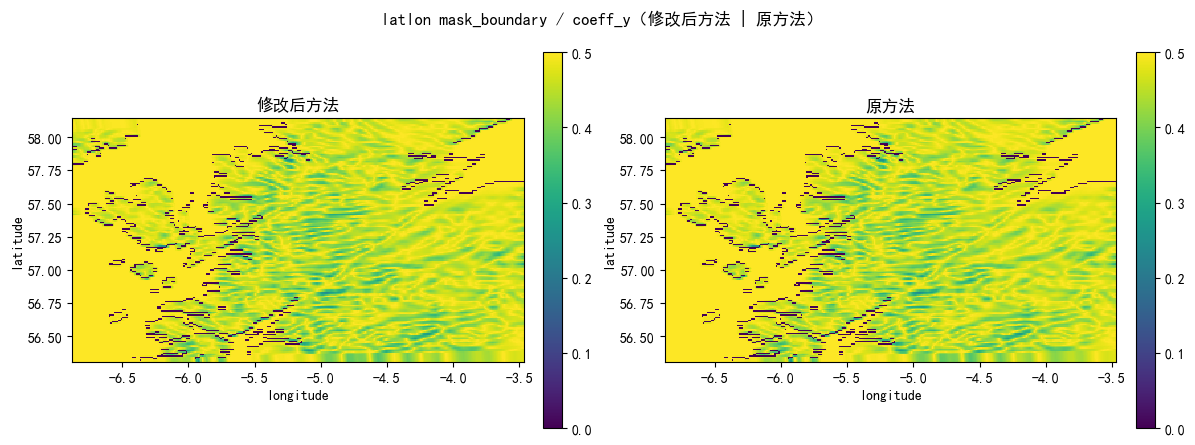

In [8]:
for key in ("basic", "mask_boundary"):
    r = latlon_results[key]
    plot_pair(f"latlon {key} / coeff_x（修改后方法 | 原方法）", r["cur_x"], r["orig_x"])
    plot_pair(f"latlon {key} / coeff_y（修改后方法 | 原方法）", r["cur_y"], r["orig_y"])



## CLI应用示例与结果对比

演示两种调用，分别与官方 KGO 及 Improver CLI 写出的 `original_cli_*.nc` 对照，三列图为 **修改后CLI | 原方法CLI | KGO**：

- `basic`（无 mask）
- `mask_boundary`（海陆掩码 + `use_mask_boundary=True`）

说明：原方法 CLI 文件由仓库根目录 `_gen_original_cli.py` 调用 Improver 命令生成。


CLI basic shapes: (1, 1, 1, 1, 100, 99) (1, 1, 1, 1, 99, 100) wrote d:\workspace\improver\generate_orographic_smoothing_coefficients\test_data\cli_outputs\cli_basic_result.nc
CLI mask_boundary shapes: (1, 1, 1, 1, 100, 99) (1, 1, 1, 1, 99, 100) wrote d:\workspace\improver\generate_orographic_smoothing_coefficients\test_data\cli_outputs\cli_mask_boundary_result.nc
CLI basic / 原方法CLI basic 均匹配 KGO。
CLI mask_boundary / 原方法CLI mask_boundary 均匹配 KGO。


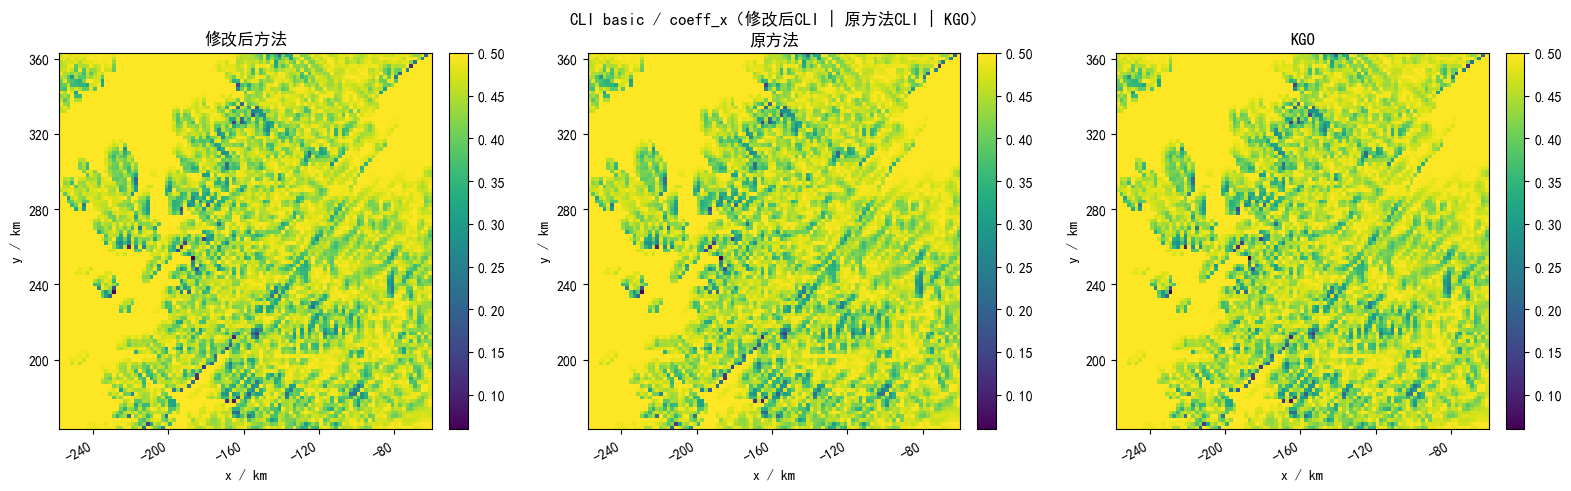

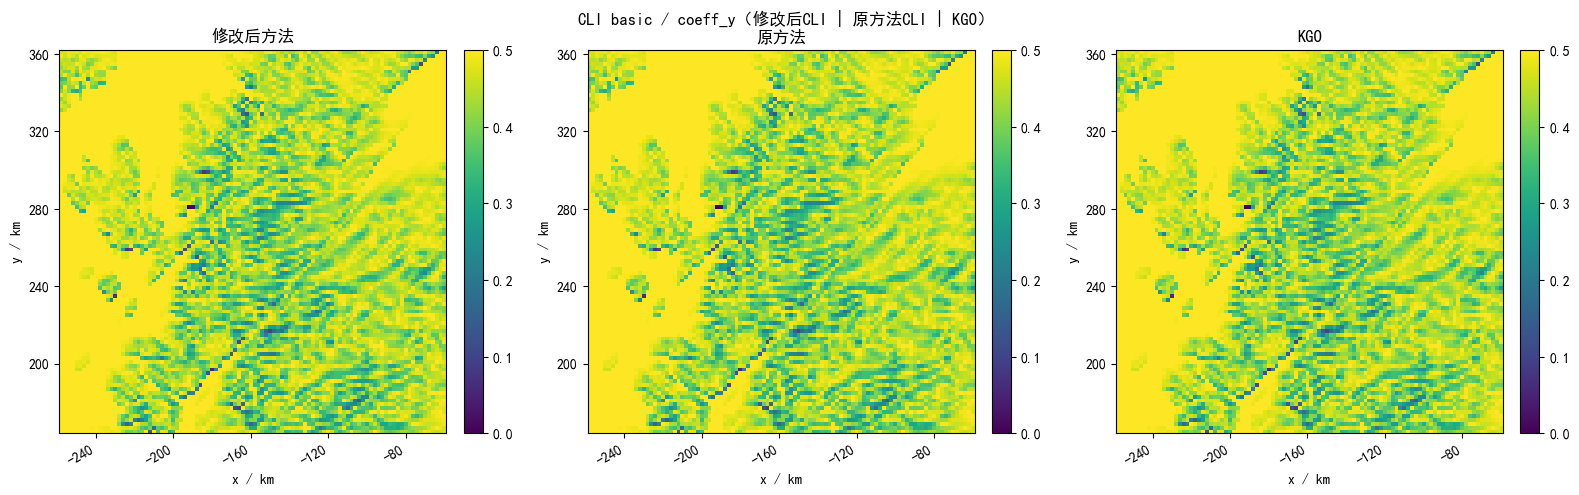

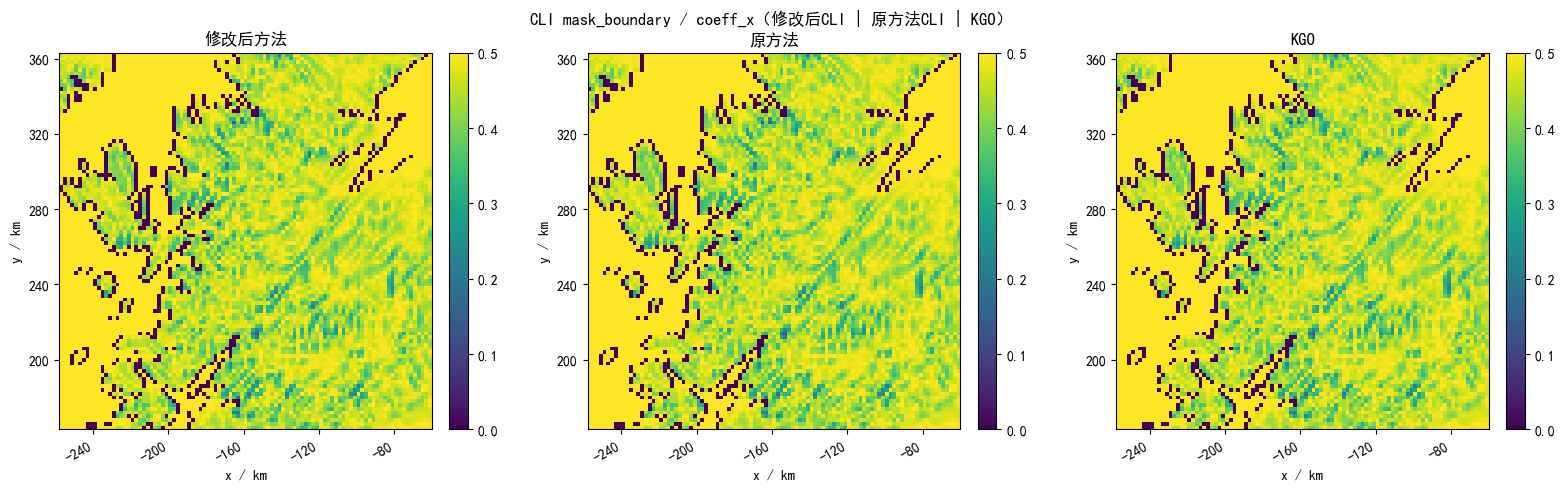

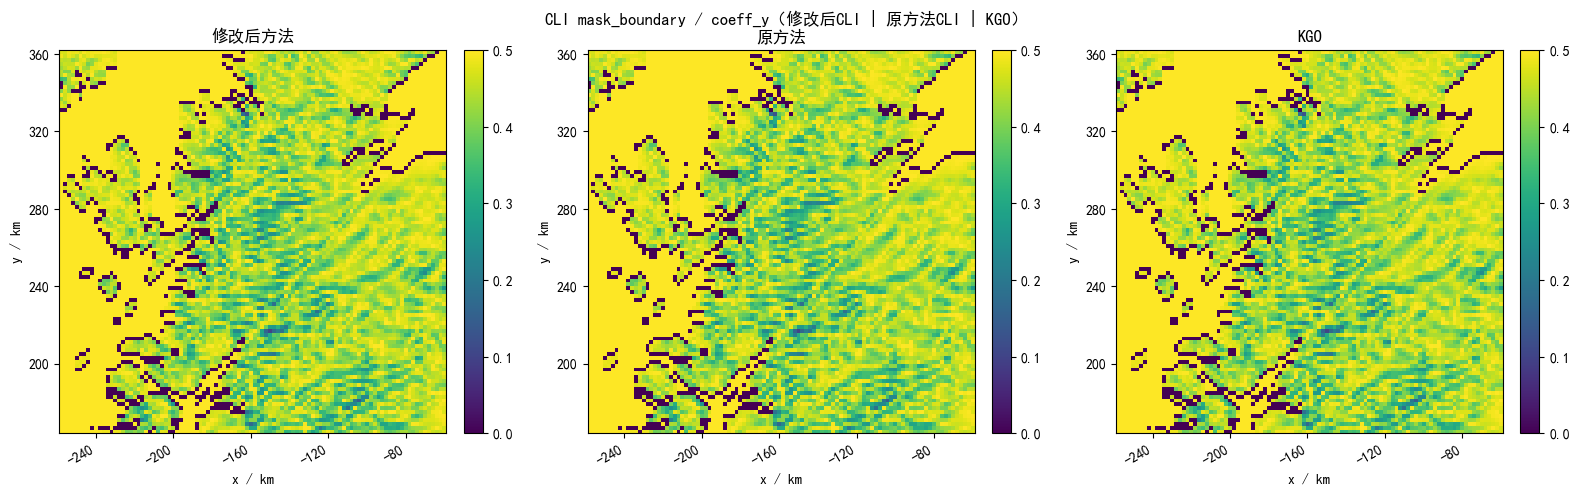

In [9]:
from generate_orographic_smoothing_coefficients.cli.anc_generate_orographic_smoothing_coefficients import (
    process as cli_process,
)

basic_out = CLI_OUTPUTS / "cli_basic_result.nc"
mask_out = CLI_OUTPUTS / "cli_mask_boundary_result.nc"

# 1) basic：无 mask
cx, cy = cli_process(
    orography_path=str(CLI_INPUTS / "input_orography_meb.nc"),
    output_path=str(basic_out),
)
print("CLI basic shapes:", cx.shape, cy.shape, "wrote", basic_out)

# 2) mask_boundary：海陆掩码 + 仅边界置零
cx2, cy2 = cli_process(
    orography_path=str(CLI_INPUTS / "input_orography_meb.nc"),
    mask_path=str(CLI_INPUTS / "input_landmask_meb.nc"),
    use_mask_boundary=True,
    output_path=str(mask_out),
)
print("CLI mask_boundary shapes:", cx2.shape, cy2.shape, "wrote", mask_out)

# 原方法 CLI 结果（Improver generate-orographic-smoothing-coefficients）
orig_cli_basic = iris.load(str(CLI_OUTPUTS / "original_cli_basic_result.nc"))
orig_cli_basic_x = orig_cli_basic.extract_cube("smoothing_coefficient_x")
orig_cli_basic_y = orig_cli_basic.extract_cube("smoothing_coefficient_y")

orig_cli_mask = iris.load(str(CLI_OUTPUTS / "original_cli_mask_boundary_result.nc"))
orig_cli_mask_x = orig_cli_mask.extract_cube("smoothing_coefficient_x")
orig_cli_mask_y = orig_cli_mask.extract_cube("smoothing_coefficient_y")

# 官方 KGO
kgo_basic = iris.load(str(TEST_ROOT / "basic" / "kgo.nc"))
kgo_basic_x = kgo_basic.extract_cube("smoothing_coefficient_x")
kgo_basic_y = kgo_basic.extract_cube("smoothing_coefficient_y")
np.testing.assert_allclose(to_2d(cx), to_2d(kgo_basic_x), atol=1e-5, rtol=1e-5)
np.testing.assert_allclose(to_2d(cy), to_2d(kgo_basic_y), atol=1e-5, rtol=1e-5)
np.testing.assert_allclose(to_2d(orig_cli_basic_x), to_2d(kgo_basic_x), atol=1e-5, rtol=1e-5)
np.testing.assert_allclose(to_2d(orig_cli_basic_y), to_2d(kgo_basic_y), atol=1e-5, rtol=1e-5)
print("CLI basic / 原方法CLI basic 均匹配 KGO。")

kgo_mask = iris.load(str(TEST_ROOT / "mask_boundary" / "kgo.nc"))
kgo_mask_x = kgo_mask.extract_cube("smoothing_coefficient_x")
kgo_mask_y = kgo_mask.extract_cube("smoothing_coefficient_y")
np.testing.assert_allclose(to_2d(cx2), to_2d(kgo_mask_x), atol=1e-5, rtol=1e-5)
np.testing.assert_allclose(to_2d(cy2), to_2d(kgo_mask_y), atol=1e-5, rtol=1e-5)
np.testing.assert_allclose(to_2d(orig_cli_mask_x), to_2d(kgo_mask_x), atol=1e-5, rtol=1e-5)
np.testing.assert_allclose(to_2d(orig_cli_mask_y), to_2d(kgo_mask_y), atol=1e-5, rtol=1e-5)
print("CLI mask_boundary / 原方法CLI mask_boundary 均匹配 KGO。")

# 绘图：修改后CLI | 原方法CLI | KGO
# plot_triplet 需要带 lat/lon coords 的 DataArray；用修改后 CLI 结果作坐标载体
def as_plot_da(template_da, values_cube):
    """把 Iris 系数场嵌到与 template 同网格的 DataArray，便于 plot_triplet。"""
    arr = to_2d(values_cube).astype(np.float32)
    out = template_da.copy(deep=True)
    # template 为六维；写回二维空间切片
    out.values[...] = arr[None, None, None, None, :, :]
    return out

plot_triplet(
    "CLI basic / coeff_x（修改后CLI | 原方法CLI | KGO）",
    cx,
    as_plot_da(cx, orig_cli_basic_x),
    as_plot_da(cx, kgo_basic_x),
)
plot_triplet(
    "CLI basic / coeff_y（修改后CLI | 原方法CLI | KGO）",
    cy,
    as_plot_da(cy, orig_cli_basic_y),
    as_plot_da(cy, kgo_basic_y),
)
plot_triplet(
    "CLI mask_boundary / coeff_x（修改后CLI | 原方法CLI | KGO）",
    cx2,
    as_plot_da(cx2, orig_cli_mask_x),
    as_plot_da(cx2, kgo_mask_x),
)
plot_triplet(
    "CLI mask_boundary / coeff_y（修改后CLI | 原方法CLI | KGO）",
    cy2,
    as_plot_da(cy2, orig_cli_mask_y),
    as_plot_da(cy2, kgo_mask_y),
)
